# Cálculo de Indicadores y KPIs — Ecocampus UPB 2026

Calcula todos los indicadores y KPIs a partir del dataset limpio producido por `limpieza_datos.ipynb`.
Los resultados se acumulan en `evisor_resultados.xlsx` (upsert por fecha: las fechas nuevas se añaden; las existentes se sobreescriben).

1. Carga del dataset limpio
2. Indicadores diarios por medidor (LF, PAR, f₁–f₄, HU, CO₂, desbalance, FP, THD-V)
3. KPIs diarios por medidor (KPI 03, 05, 08, 09, 10, 11, 12)
4. KPI 01 — Intensidad energética por bloque (kWh/m²)
5. Exportar y acumular en `evisor_resultados.xlsx`
6. Verificación de rangos

# 0. Imports

In [ ]:
# 0. Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carga del dataset limpio

In [ ]:
data = pd.read_csv("etsmartmeter_clean.csv")

#Convertimos tipos de datos
data["entity_id"] = data["entity_id"].astype("category")
data["time_index_colombia"] = pd.to_datetime(data["time_index_colombia"], errors="coerce")

# 2. Indicadores diarios

## Indicadores calculados:

**Por medidor y dia:**
- LF = promedio / maximo de potencia (curva completa del dia)
- PAR = maximo / promedio de potencia
- f1 = promedio franja diurna (07:00-21:59) / maximo del dia
- f2_CV = desviacion estandar / promedio franja diurna (coeficiente de variacion)
- f3 = minimo / promedio franja diurna
- f4 = potencia promedio nocturna (22:00-06:59) / potencia promedio diaria
- desbalance_pct = desbalance de tension entre fases v1, v2, v3

**Agregados por medidor y dia:**
- HU_horas = energia del dia (kWh) / potencia maxima (kW)
- CO2_tCO2e = 9.7018e-8 x energia del dia (Wh)
- Ahorro de energia: excluido (requiere baseline institucional definida)


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Cálculo de indicadores por medidor y día
# Dataset requerido: data con columnas [entity_id, fecha, hora, activepower,
#                    activeenergyimport, v1, v2, v3, totalpowerfactor,
#                    relativethdvoltage]
# Indicadores excluidos por falta de fuente de datos en este dataset:
#   - IGS (requiere Fronius/Enphase: energyproducedtoday, P_instalada)
#   - TCP (requiere Fronius: paneltemperature, ambienttemperature)
#   - EB  (requiere etinverterxw: energyfrombattery, energytobattery)
#   - Ahorro (requiere línea base institucional definida)
# ─────────────────────────────────────────────────────────────────────────────

##Fecha y hora
data["fecha"] = data["time_index_colombia"].dt.date
data["hora"]  = data["time_index_colombia"].dt.hour

# Parámetros de franjas horarias
HORA_OPERACIONAL_INI  = 6   # 06:00
HORA_OPERACIONAL_FIN  = 21  # hasta 21:59 inclusive
HORA_NO_OPERACIONAL_INI   = 22  # 22:00–23:59
HORA_NO_OPERACIONAL_FIN   = 5   # 00:00–05:59

# Factor de emisión XM S.A. E.S.P., preliminar 2025
FACTOR_CO2_TCO2_POR_WH = 9.7018e-8  # tCO2e / Wh

# ── Máscaras de franja ────────────────────────────────────────────────────────

def mask_operacional(df):
    return df["hora"].between(HORA_OPERACIONAL_INI, HORA_OPERACIONAL_FIN)

def mask_no_operacional(df):
    return (df["hora"] >= HORA_NO_OPERACIONAL_INI) | (df["hora"] <= HORA_NO_OPERACIONAL_FIN)

# ── Energía diaria por medidor ────────────────────────────────────────────────

energia_dia = (
    data.groupby(["entity_id", "fecha"])["activeenergyimport"]
    .agg(lambda x: x.max() - x.min())
    .rename("energia_dia_wh")
    .reset_index()
)

# ── Función principal: indicadores por grupo (entity_id + fecha) ──────────────

def calcular_indicadores(df):
    ap       = df["activepower"].dropna()
    ap_operacional  = df.loc[mask_operacional(df), "activepower"].dropna()
    ap_no_operacional = df.loc[mask_no_operacional(df), "activepower"].dropna()

    # Energía del día (Wh)
    e_dia_wh = df["activeenergyimport"].max() - df["activeenergyimport"].min()

    # LF y PAR — curva completa del día
    lf  = ap.mean() / ap.max()           if ap.max()  > 0 else np.nan
    par = ap.max()  / ap.mean()          if ap.mean() > 0 else np.nan

    # f1 — uniformidad franja diurna (06:00–21:59)
    f1  = ap_operacional.mean() / ap_operacional.max() if ap_operacional.max()  > 0 else np.nan

    # f2 — coeficiente de variación franja diurna
    f2  = ap_operacional.std()  / ap_operacional.mean() if ap_operacional.mean() > 0 else np.nan

    # f3 — relación mínimo–promedio franja diurna
    f3  = ap_operacional.min()  / ap_operacional.mean() if ap_operacional.mean() > 0 else np.nan

    # f4 — factor de carga nocturna
    f4  = ap_no_operacional.mean() / ap_operacional.mean()    if ap_operacional.mean() > 0 else np.nan

    # HU — horas de utilización  (Wh / W = h, sin constante de conversión)
    hu  = e_dia_wh / ap.max()  if ap.max()  > 0 else np.nan

    # Emisiones CO2
    co2 = FACTOR_CO2_TCO2_POR_WH * e_dia_wh

    # Desbalance de tensión (%)
    v_bar = (df["v1"] + df["v2"] + df["v3"]) / 3
    desv  = (
        df[["v1", "v2", "v3"]].subtract(v_bar, axis=0).abs().max(axis=1) / v_bar
    ) * 100
    desbalance = desv.mean()

    # Factor de potencia promedio
    fp = df["totalpowerfactor"].mean()

    # THD-V promedio
    thd_v = df["relativethdvoltage"].mean()

    return pd.Series({
        "LF":         lf,
        "PAR":        par,
        "f1":         f1,
        "f2_CV":      f2,
        "f3":         f3,
        "f4":         f4,
        "HU_horas":   hu,
        "CO2_tCO2e":  co2,
        "desbalance_pct": desbalance,
        "fp_promedio":    fp,
        "thd_v_pct":      thd_v,
    })

# ── Calcular y almacenar ──────────────────────────────────────────────────────

indicadores_diarios = (
    data
    .groupby(["entity_id", "fecha"])
    .apply(calcular_indicadores)
    .reset_index()
)

print(f"Indicadores calculados: {len(indicadores_diarios):,} registros "
      f"({indicadores_diarios['entity_id'].nunique()} medidores)")
indicadores_diarios.head()


Indicadores calculados: 465 registros (15 medidores)


,entity_id,fecha,LF,PAR,f1,f2_CV,f3,f4,HU_horas,CO2_tCO2e,desbalance_pct,fp_promedio,thd_v_pct
0,SmartMeter_SM_B10_ARQ,2026-02-10,0.616194,1.622866,0.767301,0.220373,0.571348,0.409199,14.498862,0.029602,0.590018,0.948333,2.487369
1,SmartMeter_SM_B10_ARQ,2026-02-11,0.496221,2.015233,0.613801,0.409839,0.520735,0.425316,11.528433,0.044054,0.673316,0.925475,2.351624
2,SmartMeter_SM_B10_ARQ,2026-02-12,0.658580,1.518419,0.659085,0.245693,0.565704,0.997701,15.285983,0.043069,0.589177,0.932982,2.435472
3,SmartMeter_SM_B10_ARQ,2026-02-13,0.375208,2.665189,0.470555,0.385994,0.443011,0.392118,8.812458,0.028455,0.504226,0.936988,2.299417
4,SmartMeter_SM_B10_ARQ,2026-02-14,0.627169,1.594467,0.705073,0.293432,0.551754,0.668528,14.602933,0.014544,0.395151,0.922160,1.748917


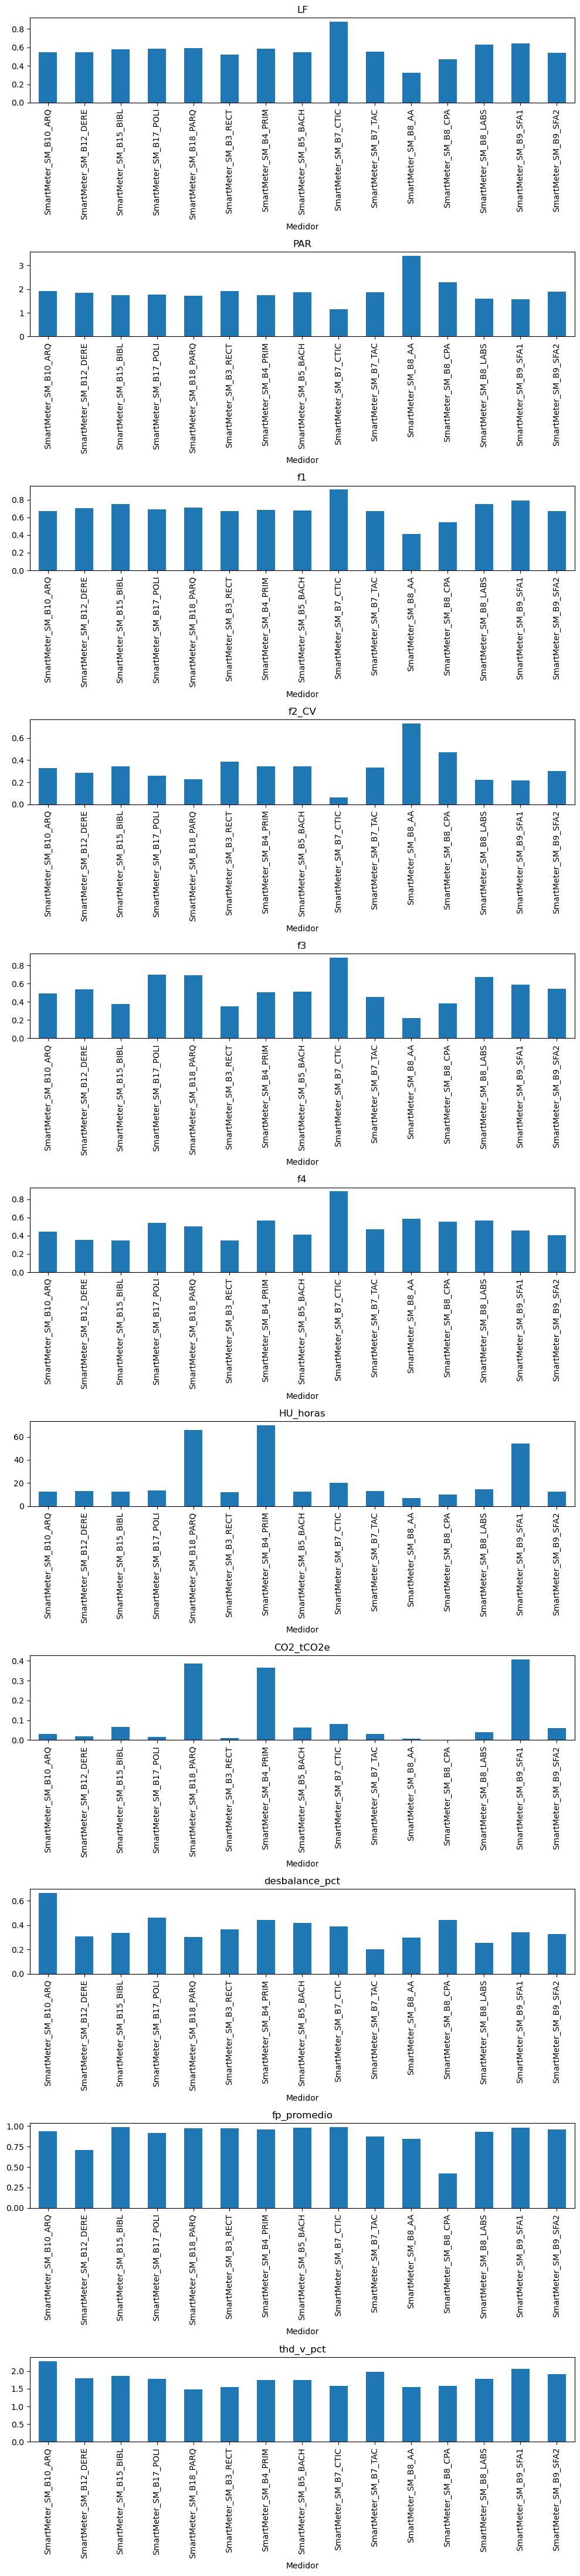

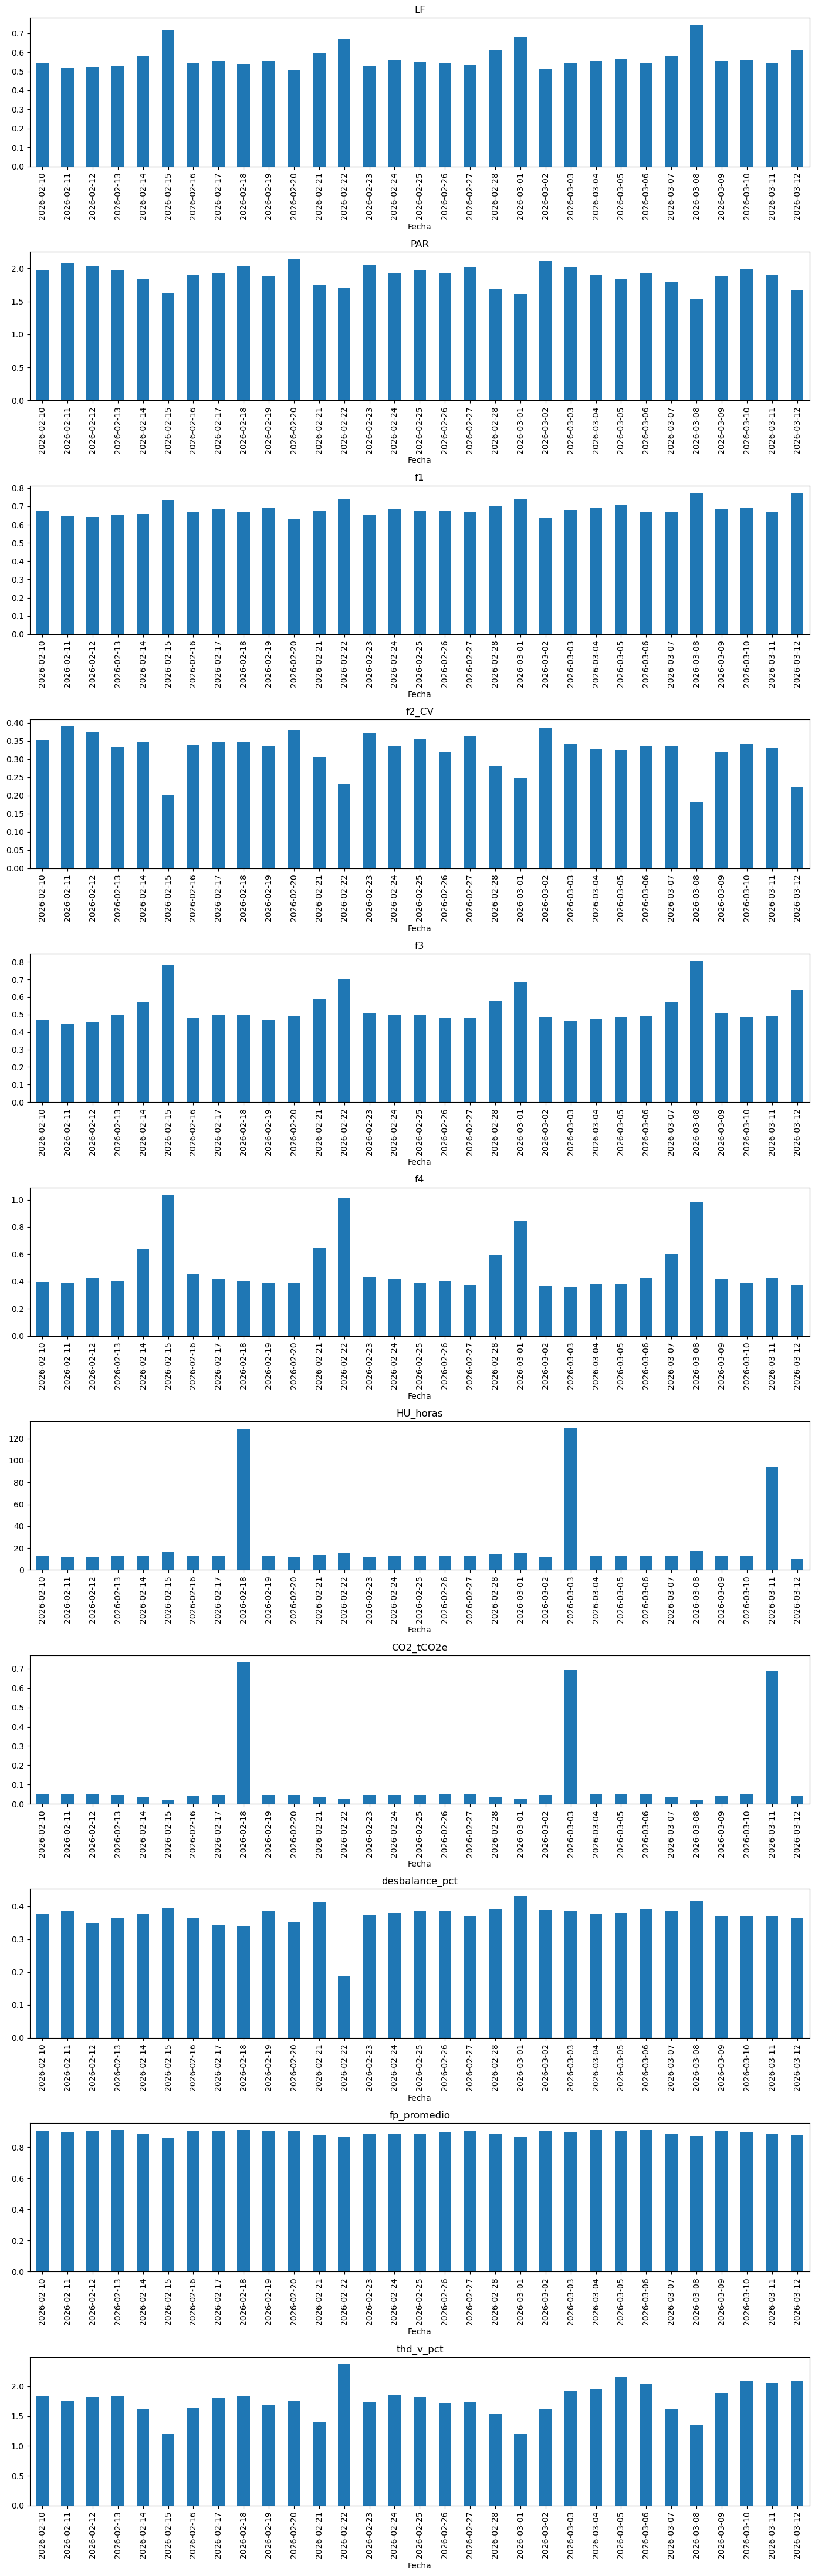

In [33]:
cols_indicadores = [
    "LF", "PAR", "f1", "f2_CV", "f3", "f4",
    "HU_horas", "CO2_tCO2e", "desbalance_pct", "fp_promedio", "thd_v_pct"
]

# Por medidor
fig, axes = plt.subplots(len(cols_indicadores), 1, figsize=(10, 4 * len(cols_indicadores)))
for ax, col in zip(axes, cols_indicadores):
    indicadores_diarios.groupby("entity_id")[col].mean().plot(kind="bar", ax=ax, title=col)
    ax.set_xlabel("Medidor")
plt.tight_layout()
plt.show()

# Por día
fig, axes = plt.subplots(len(cols_indicadores), 1, figsize=(14, 4 * len(cols_indicadores)))
for ax, col in zip(axes, cols_indicadores):
    indicadores_diarios.groupby("fecha")[col].mean().plot(kind="bar", ax=ax, title=col)
    ax.set_xlabel("Fecha")
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

# 3. KPIs diarios

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cálculo de KPIs por medidor y día — todos los KPIs en un único DataFrame
#
# KPI 01 (consumo/m²) es un indicador de nivel bloque: la energía de todos
#   los medidores del bloque se suma antes de dividir por el área (CONTEXT.md).
#   El resultado se une al nivel medidor por bloque + fecha. Para bloques con
#   varios medidores (B7 → TAC/CTIC, B8 → AA/CPA/LABS, B9 → SFA1/SFA2) el
#   KPI 01 es idéntico para todas sus filas del mismo día — correcto, porque
#   el área corresponde al bloque completo, no a un medidor individual.
#
# KPIs calculados (nivel medidor × día): 03, 05, 08, 09, 10, 11, 12
# KPI 01 (nivel bloque × día, unido al nivel medidor): consumo/m²
#
# KPIs excluidos por dependencias no resueltas:
#   - KPI 02 (intensidad/usuario): N_usuarios pendiente institucional
#   - KPI 04 (ahorro verificado): línea base del año anterior requerida
#   - KPI 06 (PR): Fronius solarirradiation no integrada
#   - KPI 07 (SS): energyproducedtoday no integrada
# ─────────────────────────────────────────────────────────────────────────────
import re

# Áreas construidas por bloque [m²] — Fuente: AREAS_2026.xlsx, Planeación Física UPB, 2026
# Bloque 18 carece de dato de Ocupación; Construcción confirmada
AREAS_BLOQUE = {
    3:   4778.68,
    4:  10309.89,
    5:  10008.87,
    7:   4834.72,
    8:   3836.47,
    9:   7579.50,
    10: 11469.06,
    12:  2848.88,
    15:  7780.01,
    17:  7611.12,
    18: 35916.80,
}

FE_2025    = 0.000097018  # tCO2e/kWh — XM S.A. E.S.P., preliminar 2025
UMBRAL_F4  = 0.20
UMBRAL_FP  = 0.9
UMBRAL_THD = 5.0

def _entity_to_bloque(eid):
    m = re.search(r'_B(\d+)_', str(eid))
    return int(m.group(1)) if m else None

# ── KPIs nivel medidor × día (03, 05, 08, 09, 10, 11, 12) ────────────────────

def calcular_kpis(df):
    ap        = df["activepower"].dropna()
    e_dia_wh  = df["activeenergyimport"].max() - df["activeenergyimport"].min()
    e_dia_kwh = e_dia_wh / 1000

    # KPI 03 — Pico de demanda
    idx_pico   = ap.idxmax()
    kpi03_kw   = ap.max()
    kpi03_hora = df.loc[idx_pico, "hora"] if idx_pico in df.index else np.nan

    # KPI 05 — Emisiones CO2
    kpi05_co2 = FE_2025 * e_dia_kwh

    # KPI 08 — Load Factor
    kpi08_lf = ap.mean() / ap.max() if ap.max() > 0 else np.nan

    # KPI 09 — Consumo no operacional (22:00–06:59) como % de la energía diaria
    #
    # El período no operacional tiene dos segmentos dentro de la misma fecha:
    #   · Madrugada : 00:00–06:59  → energía = max−min del contador en esas horas
    #   · Noche     : 22:00–23:59  → energía = max−min del contador en esas horas
    # La suma de ambos segmentos se divide por la energía total del día.
    # Fuente de energía: activeenergyimport (contador acumulado en Wh).
    e_mdrg    = df.loc[df["hora"] <= 6,  "activeenergyimport"].dropna()
    e_noct    = df.loc[df["hora"] >= 22, "activeenergyimport"].dropna()
    e_mdrg_wh = (e_mdrg.max() - e_mdrg.min()) if len(e_mdrg) >= 2 else 0.0
    e_noct_wh = (e_noct.max() - e_noct.min()) if len(e_noct) >= 2 else 0.0
    e_noche_wh = e_mdrg_wh + e_noct_wh
    kpi09_f4   = (e_noche_wh / e_dia_wh * 100) if e_dia_wh > 0 else np.nan

    # KPI 10 — Desbalance de tensión
    v_bar  = (df["v1"] + df["v2"] + df["v3"]) / 3
    db     = df[["v1","v2","v3"]].subtract(v_bar, axis=0).abs().max(axis=1) / v_bar * 100
    kpi10_db = db.mean()

    # KPI 11 — Factor de potencia
    kpi11_fp = df["totalpowerfactor"].mean()

    # KPI 12 — THD-V
    kpi12_thd = df["relativethdvoltage"].mean()

    return pd.Series({
        "KPI03_pico_kw":        kpi03_kw,
        "KPI03_hora_pico":      kpi03_hora,
        "KPI05_CO2_tCO2e":      kpi05_co2,
        "KPI08_LF":             kpi08_lf,
        "KPI09_f4_pct":         kpi09_f4,
        "KPI10_desbalance_pct": kpi10_db,
        "KPI11_fp":             kpi11_fp,
        "KPI12_thd_v_pct":      kpi12_thd,
    })

_kpis = (
    data
    .groupby(["entity_id", "fecha"])
    .apply(calcular_kpis)
    .reset_index()
)
_kpis["bloque"] = _kpis["entity_id"].apply(_entity_to_bloque)

# ── KPI 01 nivel bloque × día ─────────────────────────────────────────────────
# Paso 1: energía diaria por medidor (max−min del contador acumulado en Wh)
_e_medidor = (
    data
    .groupby(["entity_id", "fecha"])["activeenergyimport"]
    .agg(lambda x: x.max() - x.min())
    .rename("e_wh")
    .reset_index()
)
_e_medidor["bloque"] = _e_medidor["entity_id"].apply(_entity_to_bloque)

# Paso 2: sumar todos los medidores del mismo bloque → kWh → kWh/m²
_kpi01 = (
    _e_medidor
    .groupby(["bloque", "fecha"])["e_wh"]
    .sum()
    .reset_index()
)
_kpi01["area_m2"]      = _kpi01["bloque"].map(AREAS_BLOQUE)
_kpi01["KPI01_kwh_m2"] = _kpi01["e_wh"] / 1000 / _kpi01["area_m2"]
_kpi01 = _kpi01.dropna(subset=["area_m2"])

# Paso 3: unir KPI 01 al nivel medidor (bloque + fecha)
#   e_wh aquí es la energía total del bloque, no del medidor individual.
kpis_diarios = _kpis.merge(
    _kpi01[["bloque", "fecha", "e_wh", "area_m2", "KPI01_kwh_m2"]],
    on=["bloque", "fecha"],
    how="left",
)

print(f"KPIs calculados: {len(kpis_diarios):,} registros "
      f"({kpis_diarios['entity_id'].nunique()} medidores · "
      f"{kpis_diarios['bloque'].nunique()} bloques)")
kpis_diarios.head()


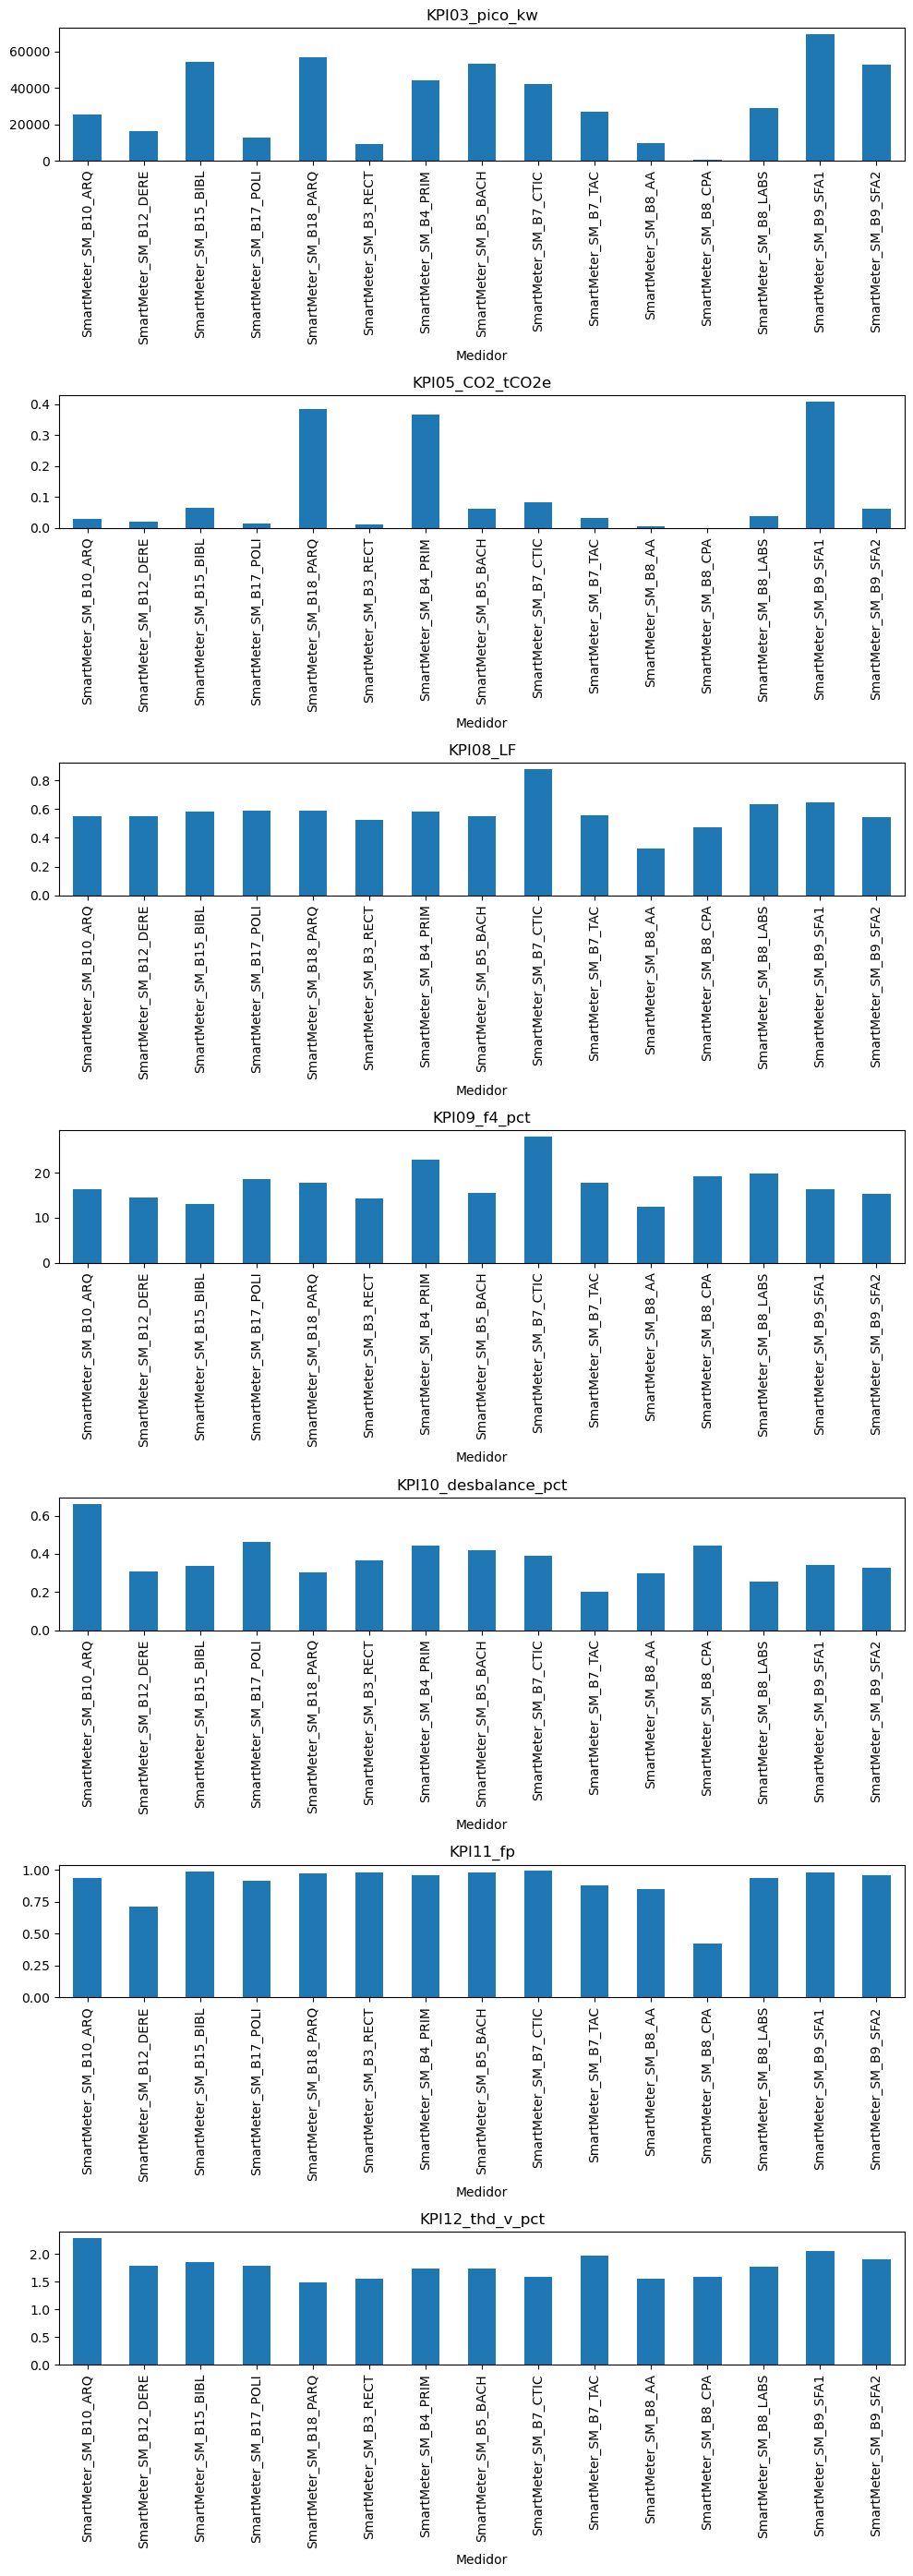

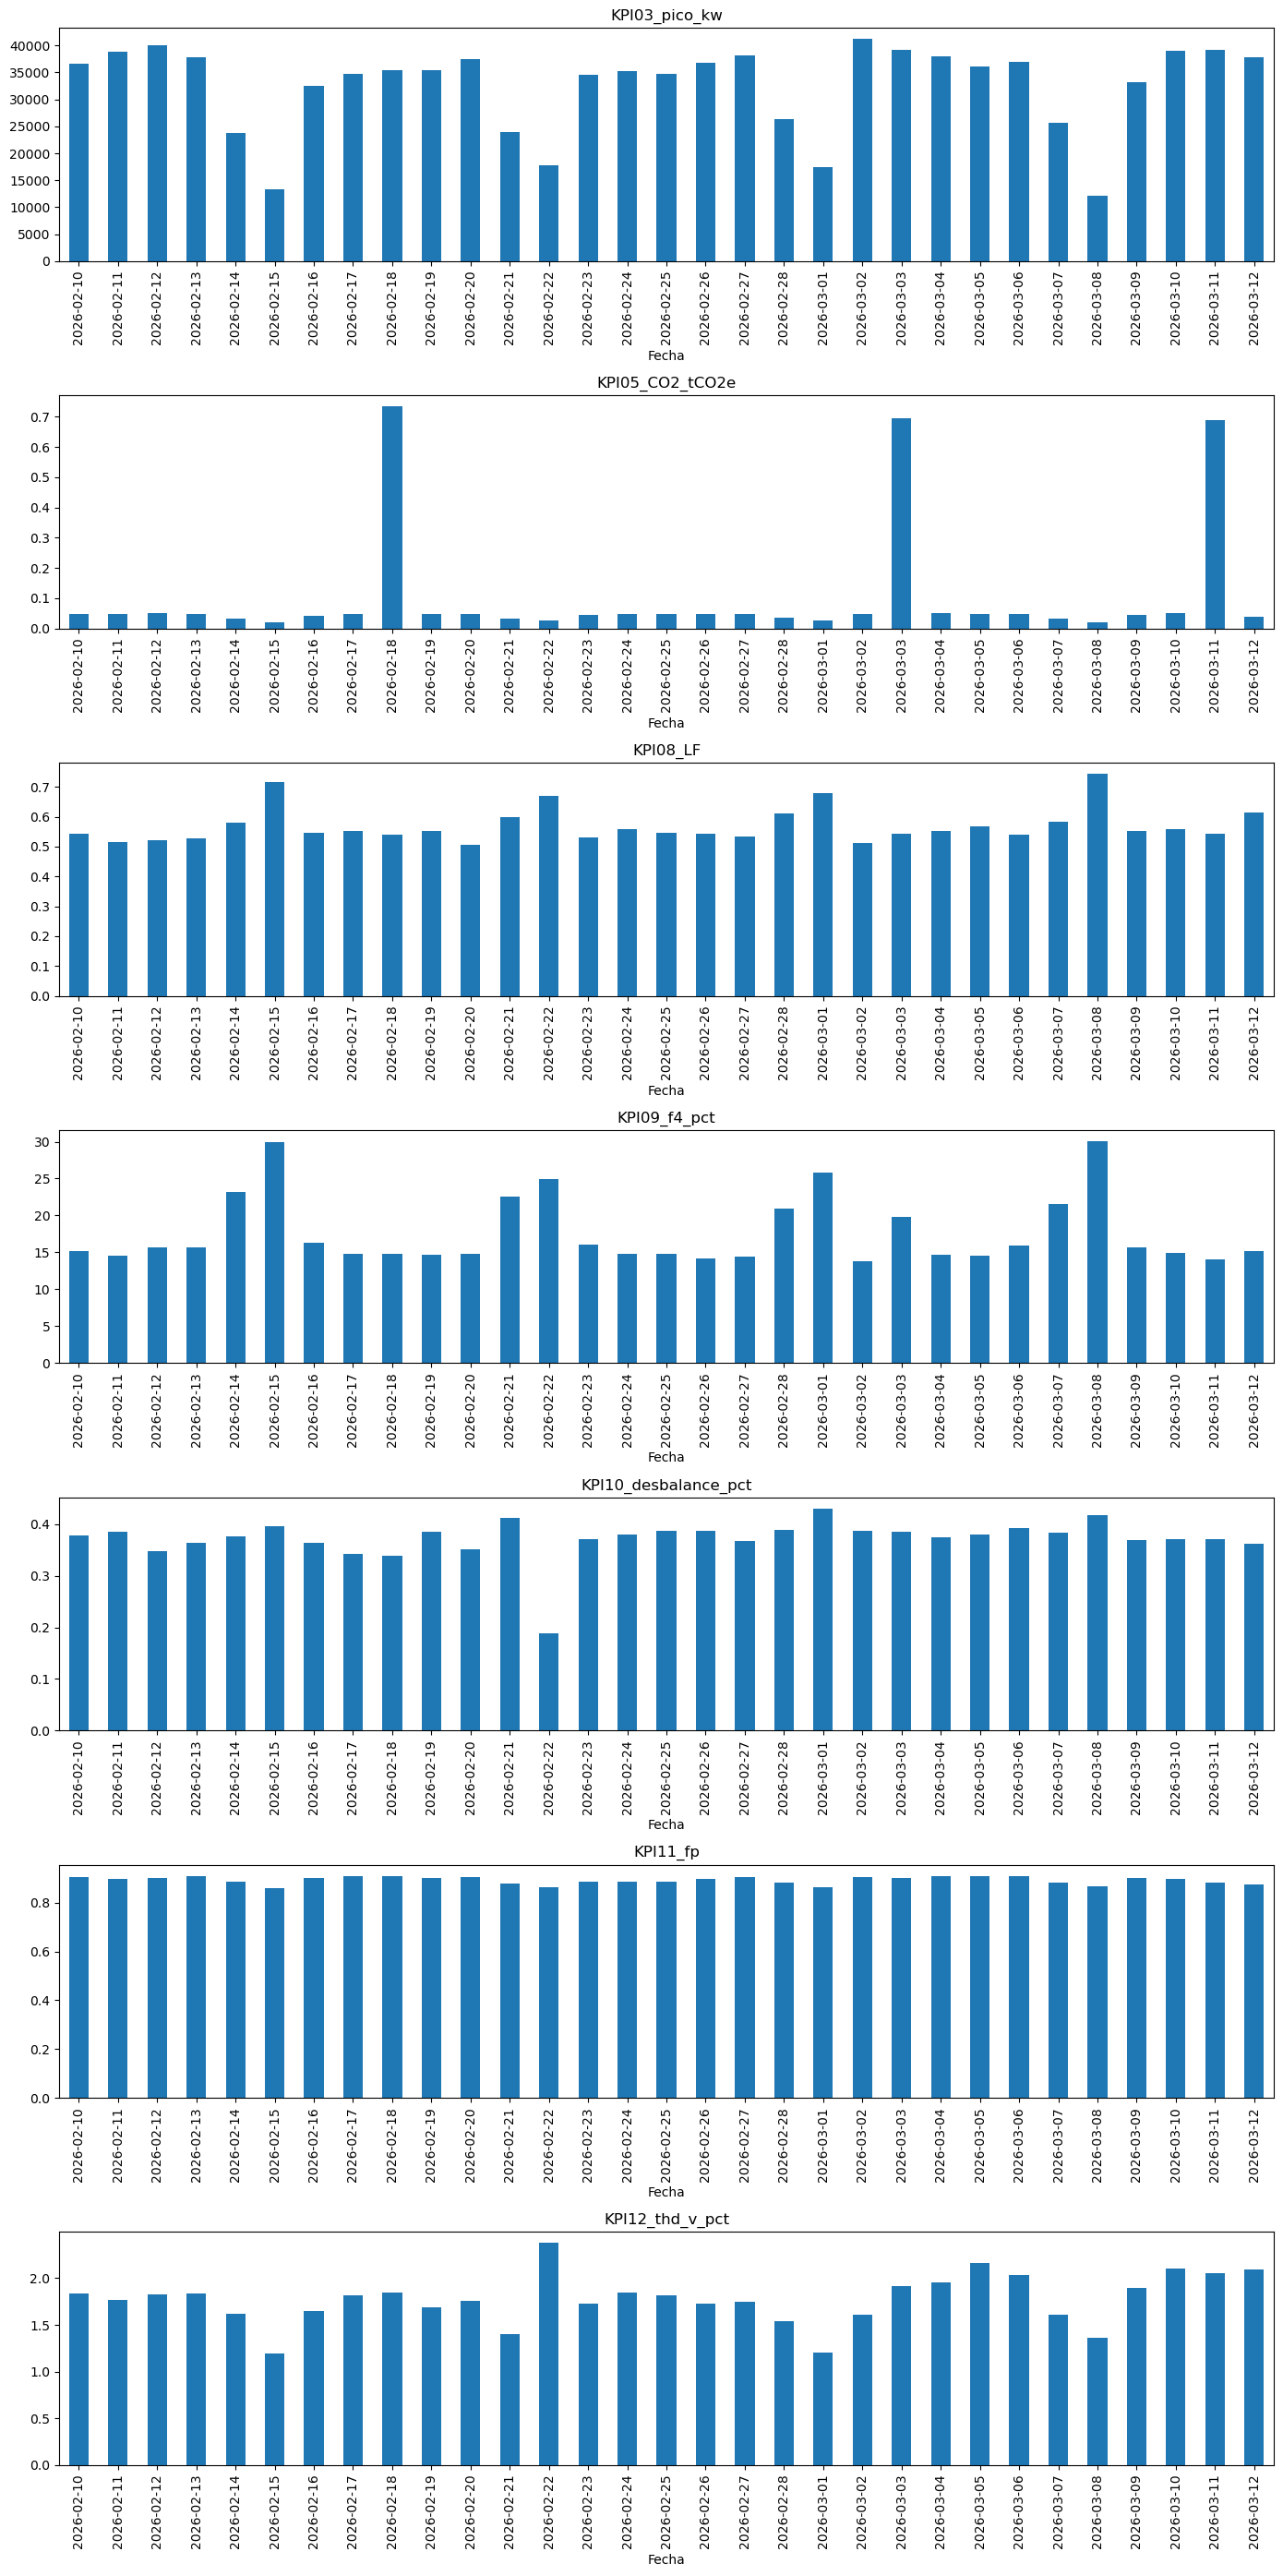

In [35]:
cols_kpis = [
    "KPI03_pico_kw", "KPI05_CO2_tCO2e", "KPI08_LF",
    "KPI09_f4_pct", "KPI10_desbalance_pct", "KPI11_fp", "KPI12_thd_v_pct"
]

# Por medidor
fig, axes = plt.subplots(len(cols_kpis), 1, figsize=(10, 4 * len(cols_kpis)))
for ax, col in zip(axes, cols_kpis):
    kpis_diarios.groupby("entity_id")[col].mean().plot(kind="bar", ax=ax, title=col)
    ax.set_xlabel("Medidor")
plt.tight_layout()
plt.show()

# Por día
fig, axes = plt.subplots(len(cols_kpis), 1, figsize=(14, 4 * len(cols_kpis)))
for ax, col in zip(axes, cols_kpis):
    kpis_diarios.groupby("fecha")[col].mean().plot(kind="bar", ax=ax, title=col)
    ax.set_xlabel("Fecha")
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

# 4. Exportar — `evisor_resultados.xlsx`

Sistema de acumulación mensual: si el archivo ya existe las fechas nuevas se añaden y las existentes se sobreescriben (upsert por `entity_id + fecha`). Ejecutar cada vez que lleguen datos de un nuevo mes.

`kpis_diarios` contiene todos los KPIs (01–12 calculados) en una sola hoja.

In [ ]:
from pathlib import Path
import pandas as pd

OUTPUT = Path("evisor_resultados.xlsx")


def _upsert(df_new, df_old, keys):
    """Append df_new to df_old; rows with same keys are overwritten (keep='last')."""
    if df_old is None or df_old.empty:
        return df_new.sort_values(keys).reset_index(drop=True)
    for df in (df_old, df_new):
        if "fecha" in df.columns:
            df["fecha"] = pd.to_datetime(df["fecha"]).dt.date
    combined = pd.concat([df_old, df_new], ignore_index=True)
    return (
        combined
        .drop_duplicates(subset=keys, keep="last")
        .sort_values(keys)
        .reset_index(drop=True)
    )


# ── leer resultados existentes ────────────────────────────────────────────────
if OUTPUT.exists():
    xl       = pd.ExcelFile(OUTPUT)
    sheets   = xl.sheet_names
    ind_ant  = xl.parse("indicadores_diarios") if "indicadores_diarios" in sheets else pd.DataFrame()
    kpis_ant = xl.parse("kpis_diarios")        if "kpis_diarios"        in sheets else pd.DataFrame()
else:
    ind_ant = kpis_ant = pd.DataFrame()

# ── upsert ────────────────────────────────────────────────────────────────────
ind_final  = _upsert(indicadores_diarios.copy(), ind_ant,  ["entity_id", "fecha"])
kpis_final = _upsert(kpis_diarios.copy(),        kpis_ant, ["entity_id", "fecha"])

# ── guardar ───────────────────────────────────────────────────────────────────
with pd.ExcelWriter(OUTPUT, engine="openpyxl") as writer:
    ind_final.to_excel(writer,  sheet_name="indicadores_diarios", index=False)
    kpis_final.to_excel(writer, sheet_name="kpis_diarios",        index=False)

print(f"\u2714 {OUTPUT.name} actualizado:")
print(f"  indicadores_diarios : {len(ind_final):>5,} registros  "
      f"({ind_final['entity_id'].nunique()} medidores \u00b7 {ind_final['fecha'].nunique()} fechas)")
print(f"  kpis_diarios        : {len(kpis_final):>5,} registros  "
      f"({kpis_final['entity_id'].nunique()} medidores \u00b7 {kpis_final['fecha'].nunique()} fechas · "
      f"KPI 01 incluido)")


# 5. Verificación de rangos de indicadores

In [37]:
# 6.6. Verificar rangos de indicadores

cols_indicadores = [
    "LF",
    "PAR",
    "f1",
    "f2_CV",
    "f3",
    "f4",
    "HU_horas",
    "CO2_tCO2e",
    "desbalance_pct",
]

indicadores_diarios[cols_indicadores].describe().T


,count,mean,std,min,25%,50%,75%,max
LF,445.0,0.570584,0.148015,0.210262,0.491355,0.549604,0.635208,0.951972
PAR,445.0,1.891548,0.604086,1.050451,1.574288,1.819490,2.035190,4.755980
f1,445.0,0.685017,0.138906,0.206646,0.614111,0.689420,0.777184,0.970749
f2_CV,445.0,0.322964,0.184170,0.016848,0.206570,0.295473,0.409440,1.095280
f3,445.0,0.534762,0.211912,0.044861,0.373675,0.533820,0.680979,0.974282
f4,445.0,0.501490,0.288301,0.129613,0.304856,0.410148,0.604316,3.196547
HU_horas,445.0,23.406476,126.949319,3.125947,11.417565,12.806077,14.817652,1763.003062
CO2_tCO2e,445.0,0.107320,0.791328,0.000209,0.015379,0.035624,0.073408,9.699000
desbalance_pct,445.0,0.372549,0.121211,0.077474,0.305900,0.355815,0.438288,0.894102
